In [18]:
import numpy as np
import scipy.stats as stats

In [26]:
# Set simulation
experiment_count = 60000
sample_size = 30 # pocet merani v jednom experimente
real_mean = 50 # Pravda, kt. poznam
alpha = 0.05 # hladina vyznamnosti

p_values = []
err_one_count = 0

print(f"Running experiment {experiment_count} times...")
print(f"Real mean: {real_mean}. Test hypothesis H0: mi_0 = {real_mean}")

#np.random.seed(42) # everytime the same "random" experiment - reproducibility

for i in range(experiment_count):
    # Generate data from KNOWN population - H0 is correct
    data = np.random.normal(loc=real_mean, scale=10, size=sample_size)

    # T-test
    t_stat, p_val = stats.ttest_1samp(data, popmean=real_mean)
    p_values.append(p_val)

    # Decide
    if p_val < alpha:
        err_one_count += 1

print("-" * 30)
print(f"Total number of error of 1. kind: {err_one_count} z {experiment_count}")
print(f"Error in percents: {err_one_count / experiment_count * 100}%")
print(f"Expected error (alpha): {alpha * 100}%")

print("-" * 30)
print(f"p-val: ", p_val)
print(f"t_stat: ", t_stat)

Running experiment 60000 times...
Real mean: 50. Test hypothesis H0: mi_0 = 50
------------------------------
Total number of error of 1. kind: 2968 z 60000
Error in percents: 4.946666666666666%
Expected error (alpha): 5.0%
------------------------------
p-val:  0.6661544254504324
t_stat:  0.43587567328608745


## Histogram

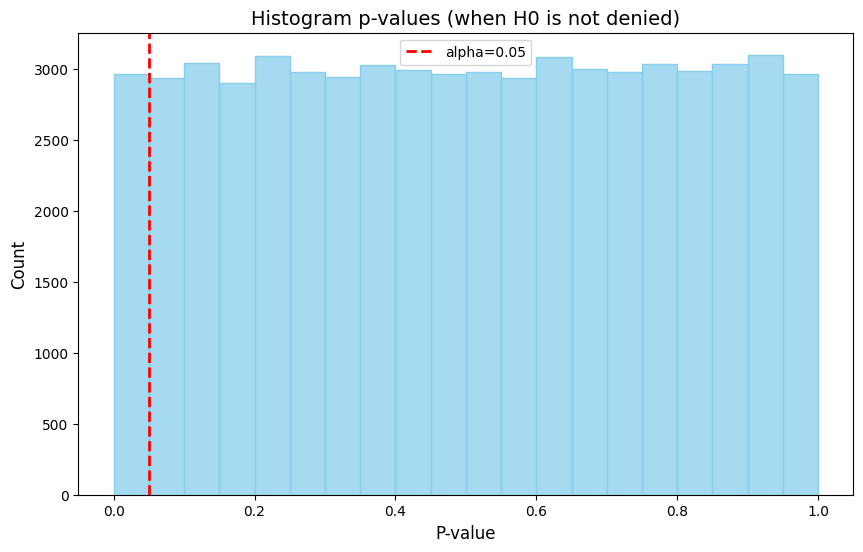

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# graph size
plt.figure(figsize=(10, 6))

# bins=20 means that we DIVIDE INTERVAL 0 to 1 na 20 cols (every col has width 0.05)
sns.histplot(p_values, bins=20, color='skyblue', edgecolor='skyblue')

# Add red dotted line for alpha = 0.05 (hladina vyznamnosti)
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label=f'alpha={alpha}')

# Titles
plt.title('Histogram p-values (when H0 is not denied)', fontsize=14)
plt.xlabel('P-value', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()

# Show graph
plt.show()

## Zhrnutie
* Všetky stlpce **naľavo od červenej čiary** (alpha=0.05) sú **chybne zamietnuté H0**. Mali platiť, ale zamietli sme ich. V tomto prípade sme chybne zamietli skoro 5% prípadov (**4.946%**), čo odpovedá našej hladine významnosti alpha. Pri iných dátach som mala  3 alebo 8 percent.
* Vidíme, že keď máme dostatok pokusov (60000), tak pravdepodobnosť pre každú p-value v rozmedzí 0-1 je pomerne rovnako distribuovaná (cca rovnaká šanca pre každé rozmedzie).
* Toto pozorovanie som nemala, keď bolo pokusov len 100, vtedy bol graf pomerne zubatý, potrebujeme dostatok dát.